# 04_analysis_report_notebook

Notebook de análisis final para consolidar hallazgos de EDA, modelado y evaluación.


In [1]:

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

paths = {
    'rrhh': [Path('../data/03_primary/rrhh_encoded.csv'), Path('data/03_primary/rrhh_encoded.csv'), Path('/home/user/rrhh_encoded.csv')],
    'clf': [Path('/home/user/output/notebooks/02_supervised_modeling_fixed.ipynb')],
    'eval': [Path('/home/user/output/notebooks/03_model_evaluation_optimization_fixed.ipynb')]
}

RUTA = next((p for p in paths['rrhh'] if p.exists()), None)
if RUTA is None:
    raise FileNotFoundError('No se encontró rrhh_encoded.csv')

df = pd.read_csv(RUTA, encoding='cp1252')
df.columns = [str(c).strip().lower().replace(' ', '_') for c in df.columns]
print('Shape:', df.shape)


Shape: (286, 62)


In [2]:

# Resumen de variables clave
cols = [c for c in ['segmento_desempeno','score_desempeno','riesgo_ausentismo'] if c in df.columns]
display(df[cols].describe(include='all').T if cols else pd.DataFrame({'mensaje':['No se encontraron columnas clave']}))


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
segmento_desempeno,286,3,Medio,161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score_desempeno,286.0,NaN,NaN,NaN,3.342867,1.741993,0.0,2.9025,3.895,4.55,6.6
riesgo_ausentismo,286,3,Normal,144,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:

# Hallazgos textuales simples
hallazgos = []
if 'segmento_desempeno' in df.columns:
    hallazgos.append(f"Distribución de segmento_desempeno: {df['segmento_desempeno'].value_counts(dropna=False).to_dict()}")
if 'score_desempeno' in df.columns:
    hallazgos.append(f"Score promedio: {pd.to_numeric(df['score_desempeno'], errors='coerce').mean():.2f}")
if 'riesgo_ausentismo' in df.columns:
    hallazgos.append(f"Riesgo ausentismo promedio: {pd.to_numeric(df['riesgo_ausentismo'], errors='coerce').mean():.2f}")

for h in hallazgos:
    print('-', h)


- Distribución de segmento_desempeno: {'Medio': 161, 'Bajo': 115, 'Alto': 10}
- Score promedio: 3.34
- Riesgo ausentismo promedio: nan


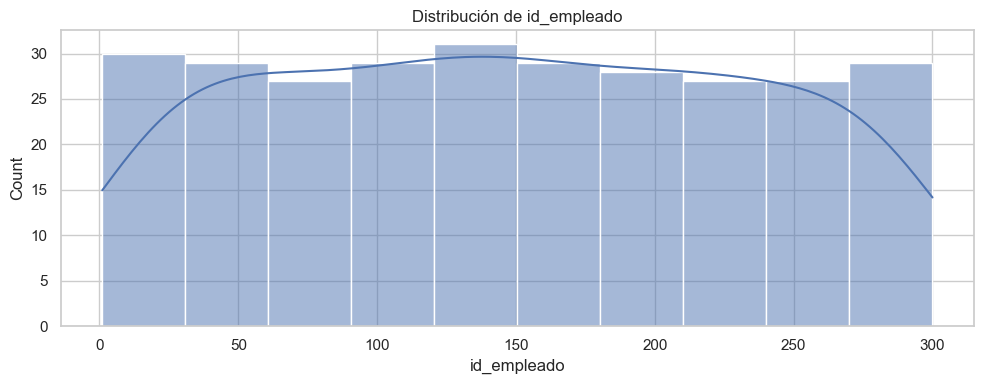

In [4]:

# Visual simple
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if num_cols:
    plt.figure(figsize=(10,4))
    sns.histplot(df[num_cols[0]].dropna(), kde=True)
    plt.title(f'Distribución de {num_cols[0]}')
    plt.tight_layout()
    plt.show()
